In [1]:
import numpy as np
import optuna
SEED = 42

import random
import tensorflow as tf

import os
def init_seed(s):
    seed = s
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINSTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINSTIC"] = "1"
    np.random.seed(seed)
    tf.config.experimental.enable_op_determinism()
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

c:\Users\natha\Documents\Git\5th-year-polytech\deep_learning\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, X_val, X_test = np.random.uniform(-2, 2, 2000), np.random.uniform(-2, 2, 1000), np.random.uniform(-2, 2, 1000)

y_train = np.where((X_train > 0.5) | (X_train <= -0.5), 0.0, 1.0).astype(np.float32).reshape(-1, 1)
y_val   = np.where((X_val   > 0.5) | (X_val   <= -0.5), 0.0, 1.0).astype(np.float32).reshape(-1, 1)
y_test  = np.where((X_test  > 0.5) | (X_test  <= -0.5), 0.0, 1.0).astype(np.float32).reshape(-1, 1)

In [3]:
from keras import layers, Model, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

In [4]:
init_seed(2025)

In [ ]:
patience = 20

callbacks = [
    EarlyStopping(monitor = "val_accuracy", patience = patience, mode = "max", verbose = 1),
]

In [6]:
n_unit1 = 32
n_unit2 = 64
n_unit3 = 128
learning_rate = 10**-3
activation = "relu"

input = Input(shape=(1, ))
x1 = layers.Dense(n_unit1, activation=activation)(input)
x2 = layers.Dense(n_unit2, activation=activation)(x1)
x3 = layers.Dense(n_unit3, activation=activation)(x2)
output = layers.Dense(1, activation = "sigmoid")(x3)

model = Model(input, output)

In [7]:
from keras import losses, metrics

model.compile(optimizer=Adam(learning_rate=learning_rate), loss = losses.binary_crossentropy, metrics = [metrics.Accuracy])
history = model.fit(X_train, y_train, batch_size=128, epochs=300, validation_data=(X_val, y_val), verbose = 1, callbacks=callbacks)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0000e+00 - loss: 0.5872 - val_accuracy: 0.0000e+00 - val_loss: 0.4746
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.4203 - val_accuracy: 0.0000e+00 - val_loss: 0.3726
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.3499 - val_accuracy: 0.0000e+00 - val_loss: 0.3197
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.2992 - val_accuracy: 0.0000e+00 - val_loss: 0.2702
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.2521 - val_accuracy: 0.0000e+00 - val_loss: 0.2272
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.2095 - val_accuracy: 0.0000e+00 - val_loss: 0.1867
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.1688 - val_accuracy: 0.0000e+00 - val_loss: 0.1472
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

In [8]:
y_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


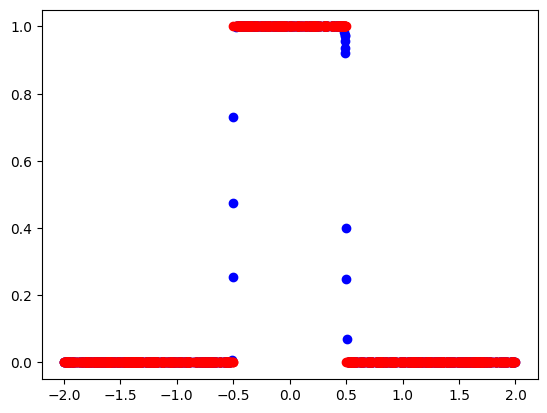

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x = X_test, y = y_pred, color = "blue")
plt.scatter(x = X_test, y = y_test, color = "red")